# BasicViT v3 - ViT-Base with Pretrained Checkpoint (Windows Local)
Fine-tune pretrained ViT-Base on HMDB-51, compare with LS-ViT

**Notebook này được điều chỉnh để chạy local trên Windows**


In [1]:
# Install packages if needed (uncomment if running for the first time)
# !pip install torch torchvision timm tqdm pillow matplotlib numpy

# Fix NumPy compatibility: Downgrade from 2.4.0rc1 to stable 2.3.x
# NumPy 2.4.0rc1 has compatibility issues with matplotlib 3.10.8
import numpy as np
if np.__version__.startswith('2.4'):
    print("⚠️  NumPy 2.4.0rc1 detected - has compatibility issues with matplotlib")
    print("   Downgrading to NumPy 2.3.x for stability...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy<2.4", "--quiet"])
    print("✅ NumPy downgraded. Please restart kernel and run cells again.")
    raise RuntimeError("Please restart kernel after NumPy downgrade")
else:
    print(f"✅ NumPy version {np.__version__} is compatible")


✅ NumPy version 2.3.5 is compatible


In [2]:
# Extract HMDB51.zip if data folder doesn't exist
import zipfile
import os
from pathlib import Path

DATA_DIR = './hmdb51_data'
ZIP_FILE = './HMDB51.zip'

if not os.path.exists(DATA_DIR):
    if os.path.exists(ZIP_FILE):
        print(f"Extracting {ZIP_FILE} to {DATA_DIR}...")
        os.makedirs(DATA_DIR, exist_ok=True)
        with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)
        print("Extraction complete!")
    else:
        print(f"Warning: {ZIP_FILE} not found. Please ensure HMDB51.zip is in the current directory.")
else:
    print(f"Data directory {DATA_DIR} already exists. Skipping extraction.")


Data directory ./hmdb51_data already exists. Skipping extraction.


In [3]:
from __future__ import annotations
import math
import random
from pathlib import Path
from typing import Optional, Tuple, Dict, List
import re

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Workaround settings cho RTX 5090 (set trước khi dùng GPU)
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
torch.backends.cudnn.benchmark = False  # Disable cuDNN auto-tuning for RTX 5090

# Import torchvision với error handling
try:
    from torchvision import transforms
    import torchvision.transforms.functional as TF
    TORCHVISION_AVAILABLE = True
except RuntimeError as e:
    if "operator torchvision::nms does not exist" in str(e):
        print("⚠️  Lỗi: torchvision không tương thích với PyTorch")
        print("   Giải pháp: Đóng Jupyter notebook HOÀN TOÀN và chạy lệnh sau trong terminal:")
        print("   conda activate pytorch_gpu")
        print("   pip uninstall -y torchvision")
        print("   pip install torchvision --index-url https://download.pytorch.org/whl/cu128")
        print("   Sau đó mở lại notebook và restart kernel")
        raise
    else:
        raise

from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import timm

# Use GPU if available (no CPU fallback)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

# Check GPU info
if torch.cuda.is_available():
    print(f'CUDA version: {torch.version.cuda}')
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')
    
    if "5090" in torch.cuda.get_device_name(0):
        if "2.9.1" in torch.__version__:
            print('\n✅ RTX 5090 detected with PyTorch 2.9.1')
            print('   Note: Some CUDA kernels may not be fully supported yet')
            print('   Run the GPU test cell below to verify compatibility')
        else:
            print('\n⚠️  RTX 5090 detected!')
            print(f'   Current PyTorch: {torch.__version__} may have CUDA compatibility issues')
            print('   Upgrade to PyTorch 2.9.1 with CUDA 12.8 for better RTX 5090 support')
            print('   Run the installation cell below, then restart kernel.')
else:
    print('⚠️  No GPU detected - training will be slow on CPU')


Device: cuda
PyTorch version: 2.9.1+cu128
CUDA version: 12.8
GPU: NVIDIA GeForce RTX 5090
GPU Memory: 31.84 GB

✅ RTX 5090 detected with PyTorch 2.9.1
   Note: Some CUDA kernels may not be fully supported yet
   Run the GPU test cell below to verify compatibility


## ⚠️ QUAN TRỌNG: Nếu vẫn gặp lỗi CUDA sau khi restart kernel

**Nếu bạn vẫn gặp lỗi "no kernel image is available" sau khi restart kernel**, có thể một số CUDA kernels chưa được compile cho RTX 5090.

**Giải pháp tạm thời:** Chạy cell bên dưới để test và thử workaround.


In [4]:
# Test GPU và thử workaround cho RTX 5090
import os

# Workaround settings cho RTX 5090
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
torch.backends.cudnn.benchmark = False  # Disable cuDNN auto-tuning
torch.backends.cudnn.enabled = True

print("Testing GPU with RTX 5090 workaround...")
print("=" * 60)

try:
    # Test 1: Simple tensor operation
    x = torch.randn(2, 3, 224, 224).cuda()
    print("✓ Test 1: Tensor creation on GPU - SUCCESS")
    
    # Test 2: Conv2d operation (thường gây lỗi)
    conv = nn.Conv2d(3, 64, 3, padding=1).cuda()
    y = conv(x)
    print("✓ Test 2: Conv2d on GPU - SUCCESS")
    
    # Test 3: ViT patch embedding (operation gây lỗi trong training)
    patch_embed = nn.Conv2d(3, 768, kernel_size=16, stride=16).cuda()
    z = patch_embed(x)
    print("✓ Test 3: Patch embedding (ViT) on GPU - SUCCESS")
    
    print("\n" + "=" * 60)
    print("✅ ALL GPU TESTS PASSED!")
    print("GPU should work for training.")
    print("\nIf training still fails, try:")
    print("- Reduce BATCH_SIZE to 4 or 2")
    print("- Close and reopen Jupyter notebook")
    print("=" * 60)
    
except RuntimeError as e:
    if "kernel image" in str(e) or "CUDA" in str(e):
        print("\n" + "=" * 60)
        print("❌ GPU TEST FAILED - CUDA kernel error")
        print(f"\nError: {str(e)[:200]}")
        print("\n⚠️  RTX 5090 (sm_120) không được hỗ trợ đầy đủ bởi PyTorch 2.9.1")
        print("\nGiải pháp:")
        print("1. Đóng Jupyter notebook HOÀN TOÀN và mở lại")
        print("2. Restart máy tính để clear CUDA cache")
        print("3. Thử PyTorch nightly (cần đóng notebook trước khi cài)")
        print("4. Tạm thời dùng CPU (chậm nhưng hoạt động)")
        print("\nĐể dùng CPU, set DEVICE = torch.device('cpu') trong cell import")
        print("=" * 60)
        
        # Không raise error, chỉ cảnh báo
        print("\n⚠️  Continuing with warning - training may fail on GPU")
    else:
        raise


Testing GPU with RTX 5090 workaround...
✓ Test 1: Tensor creation on GPU - SUCCESS
✓ Test 2: Conv2d on GPU - SUCCESS
✓ Test 3: Patch embedding (ViT) on GPU - SUCCESS

✅ ALL GPU TESTS PASSED!
GPU should work for training.

If training still fails, try:
- Reduce BATCH_SIZE to 4 or 2
- Close and reopen Jupyter notebook


## Cài PyTorch 2.9.1 cho RTX 5090

Nếu gặp lỗi CUDA, chạy cell bên dưới để cài PyTorch 2.9.1
 pytouch 2.9.1

In [5]:
# Cài PyTorch 2.9.1 với CUDA 12.8 cho RTX 5090 (Đã cài trong môi trường pytorch_gpu)
# Chạy cell này nếu cần cài lại

print("Cài PyTorch 2.9.1 với CUDA 12.8 cho RTX 5090...")
print("Sau khi cài xong, restart kernel và chạy lại từ đầu!")

%pip uninstall -y torch torchvision torchaudio
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

print("\n✅ Cài đặt hoàn tất!")
print("⚠️  QUAN TRỌNG: Restart kernel (Kernel -> Restart Kernel) và chạy lại từ đầu!")


Cài PyTorch 2.9.1 với CUDA 12.8 cho RTX 5090...
Sau khi cài xong, restart kernel và chạy lại từ đầu!
Found existing installation: torch None
Note: you may need to restart the kernel to use updated packages.


error: uninstall-no-record-file

× Cannot uninstall torch None
╰─> The package's contents are unknown: no RECORD file was found for torch.

hint: You might be able to recover from this via: pip install --force-reinstall --no-deps torch==2.9.1+cu126


Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.

✅ Cài đặt hoàn tất!
⚠️  QUAN TRỌNG: Restart kernel (Kernel -> Restart Kernel) và chạy lại từ đầu!


## 1. Dataset Classes


In [6]:
class VideoTransform:
    """Data augmentation - giống LS-ViT"""
    def __init__(self, mode='train', image_size=224):
        self.is_train = (mode == 'train')
        self.image_size = image_size
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __call__(self, frames: torch.Tensor) -> torch.Tensor:
        # frames: [T, C, H, W]
        if self.is_train:
            # Random resized crop
            h, w = frames.shape[-2:]
            scale = random.uniform(0.8, 1.0)
            new_h, new_w = int(h * scale), int(w * scale)
            frames = TF.resize(frames, [new_h, new_w], interpolation=transforms.InterpolationMode.BILINEAR)

            # Random crop
            i = random.randint(0, max(0, new_h - self.image_size))
            j = random.randint(0, max(0, new_w - self.image_size))
            frames = TF.crop(frames, i, j, min(self.image_size, new_h), min(self.image_size, new_w))
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

            # Horizontal flip
            if random.random() < 0.5:
                frames = TF.hflip(frames)
        else:
            # Val: center crop
            frames = TF.resize(frames, [self.image_size, self.image_size], interpolation=transforms.InterpolationMode.BILINEAR)

        # Normalize
        normalized = [TF.normalize(frame, self.mean, self.std) for frame in frames]
        return torch.stack(normalized)


class HMDB51Dataset(Dataset):
    """Load HMDB51 video frames with grouped train/val split - giống LS-ViT"""
    def __init__(self, root: str, split: str, num_frames: int = 16, frame_stride: int = 1,
                 image_size: int = 224, val_ratio: float = 0.1, seed: int = 42):
        super().__init__()
        self.root = Path(root)
        if not self.root.is_dir():
            raise FileNotFoundError(f"Data root not found: {self.root}")

        self.classes = sorted([d.name for d in self.root.iterdir() if d.is_dir()])
        if not self.classes:
            raise RuntimeError(f"No class folders in {self.root}")
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

        # Group videos by (class, base_video_name)
        grouped_samples: Dict[Tuple[str, str], List[Tuple[List[Path], int]]] = {}
        for cls in self.classes:
            cls_dir = self.root / cls
            for video_dir in sorted([d for d in cls_dir.iterdir() if d.is_dir()]):
                frame_paths = sorted([p for p in video_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
                if not frame_paths:
                    continue
                group_key = (cls, self._base_video_name(video_dir.name))
                grouped_samples.setdefault(group_key, []).append((frame_paths, self.class_to_idx[cls]))

        if not grouped_samples:
            raise RuntimeError(f"No frame folders found inside {self.root}")

        # Split groups (not individual samples)
        group_values = list(grouped_samples.values())
        rng = np.random.RandomState(seed)
        group_indices = np.arange(len(group_values))
        rng.shuffle(group_indices)
        split_point = int(len(group_indices) * (1 - val_ratio))

        if split == "train":
            selected_groups = group_indices[:split_point]
        elif split in ("val", "test"):
            selected_groups = group_indices[split_point:]
        else:
            raise ValueError(f"Unknown split: {split}")

        # Collect samples from selected groups
        samples: List[Tuple[List[Path], int]] = []
        for idx in selected_groups:
            samples.extend(group_values[int(idx)])

        if not samples:
            raise RuntimeError("Selected split has no samples; adjust val_ratio or data folders.")

        self.samples = samples
        self.split = split
        self.num_frames = num_frames
        self.frame_stride = max(1, frame_stride)
        self.transform = VideoTransform(mode='train' if split == 'train' else 'val', image_size=image_size)
        self.to_tensor = transforms.ToTensor()

    def __len__(self) -> int:
        return len(self.samples)

    def _select_indices(self, total: int) -> torch.Tensor:
        """Select frame indices uniformly"""
        if total <= 0:
            raise ValueError("Video folder has no frames")
        if total == 1:
            return torch.zeros(self.num_frames, dtype=torch.long)
        steps = max(self.num_frames * self.frame_stride, self.num_frames)
        grid = torch.linspace(0, total - 1, steps=steps)
        idxs = grid[:: self.frame_stride].long()
        if idxs.numel() < self.num_frames:
            pad = idxs.new_full((self.num_frames - idxs.numel(),), idxs[-1].item())
            idxs = torch.cat([idxs, pad], dim=0)
        return idxs[: self.num_frames]

    @staticmethod
    def _base_video_name(name: str) -> str:
        """Remove trailing _N from video name"""
        match = re.match(r"(.+)_\d+$", name)
        return match.group(1) if match else name

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        frame_paths, label = self.samples[idx]
        total = len(frame_paths)
        idxs = self._select_indices(total)

        frames = []
        for i in idxs:
            path = frame_paths[int(i.item())]
            with Image.open(path) as img:
                img = img.convert("RGB")
                frames.append(self.to_tensor(img))

        video = torch.stack(frames)
        video = self.transform(video)
        return video, label


def collate_fn(batch: List[Tuple[torch.Tensor, int]]) -> Tuple[torch.Tensor, torch.Tensor]:
    videos = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.long)
    return videos, labels

print(" Dataset classes defined (copy from LS-ViT)")


 Dataset classes defined (copy from LS-ViT)


In [7]:
DATA_ROOT = './hmdb51_data'
VAL_RATIO = 0.1
SEED = 42
NUM_FRAMES = 16
FRAME_STRIDE = 2
IMG_SIZE = 224
BATCH_SIZE = 12  # Optimized for video data (16 frames): 12 works well with 32GB VRAM
# Note: With 16 frames per video, memory usage is high. 
# Batch 12 ≈ 12-15GB memory, batch 16 ≈ 18-22GB, batch 32 will OOM
# Windows: Use 0 workers to avoid multiprocessing issues
NUM_WORKERS = 0

train_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='train',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)
val_dataset = HMDB51Dataset(
    root=DATA_ROOT,
    split='val',
    num_frames=NUM_FRAMES,
    frame_stride=FRAME_STRIDE,
    image_size=IMG_SIZE,
    val_ratio=VAL_RATIO,
    seed=SEED,
)

print(f" Train clips: {len(train_dataset)} | Val clips: {len(val_dataset)}")
print(f" Class count: {len(train_dataset.classes)}")

# Show samples
if len(train_dataset) > 0:
    sample_video, sample_label = train_dataset[0]
    print(f"\nTrain sample: {sample_video.shape} - {train_dataset.classes[sample_label]}")

if len(val_dataset) > 0:
    sample_video, sample_label = val_dataset[0]
    print(f"Val sample: {sample_video.shape} - {val_dataset.classes[sample_label]}")


 Train clips: 6119 | Val clips: 647
 Class count: 51

Train sample: torch.Size([16, 3, 224, 224]) - catch
Val sample: torch.Size([16, 3, 224, 224]) - smoke


## 3. Create DataLoaders


In [8]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f" Train batches: {len(train_loader)}")
print(f" Val batches: {len(val_loader)}")


 Train batches: 510
 Val batches: 54


## 4. ViT-Base Architecture (Build from Scratch)


In [9]:
class PatchEmbedding(nn.Module):
    """Convert image to patch embeddings"""
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int):
        super().__init__()
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) -> (B, num_patches, embed_dim)"""
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x

print("PatchEmbedding defined")


PatchEmbedding defined


In [10]:
class Attention(nn.Module):
    """Multi-head self-attention"""
    def __init__(self, dim: int, num_heads: int = 12, attn_drop: float = 0.0, proj_drop: float = 0.0):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """(B, N, dim) -> (B, N, dim)"""
        B, N, C = x.shape

        # QKV projection
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, B, num_heads, N, head_dim)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # Attention
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        # Apply to values
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

print("Attention defined")


Attention defined


In [11]:
class Mlp(nn.Module):
    """MLP block"""
    def __init__(self, in_features: int, hidden_features: int = None, out_features: int = None, drop: float = 0.0):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features

        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

print("Mlp defined")


Mlp defined


In [12]:
class TransformerBlock(nn.Module):
    """Transformer block (Attention + MLP)"""
    def __init__(self, dim: int, num_heads: int = 12, mlp_ratio: float = 4.0,
                 drop: float = 0.0, attn_drop: float = 0.0):
        super().__init__()

        # Attention path
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, attn_drop=attn_drop, proj_drop=drop)

        # MLP path
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp = Mlp(in_features=dim, hidden_features=mlp_hidden, drop=drop)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Residual attention
        x = x + self.attn(self.norm1(x))
        # Residual MLP
        x = x + self.mlp(self.norm2(x))
        return x

print("TransformerBlock defined")


TransformerBlock defined


In [13]:
class ViTBase(nn.Module):
    """ViT-Base from scratch (vit_base_patch16_224 architecture)

    Specs:
    - Image size: 224
    - Patch size: 16
    - Embed dim: 768
    - Depth: 12
    - Num heads: 12
    - MLP ratio: 4.0
    """

    def __init__(self, image_size: int = 224, patch_size: int = 16, in_channels: int = 3,
                 embed_dim: int = 768, depth: int = 12, num_heads: int = 12,
                 mlp_ratio: float = 4.0, drop_rate: float = 0.0, attn_drop_rate: float = 0.0):
        super().__init__()

        self.embed_dim = embed_dim

        # Patch embedding
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches  # 196 for 224x224, patch_size=16

        # Class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(drop_rate)

        # Transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, mlp_ratio, drop_rate, attn_drop_rate)
            for _ in range(depth)
        ])

        # Layer norm
        self.norm = nn.LayerNorm(embed_dim)

        # Initialize weights
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward_features(self, x: torch.Tensor) -> torch.Tensor:
        """Extract features without classification head"""
        B = x.shape[0]

        # Patch embedding
        x = self.patch_embed(x)  # (B, num_patches, embed_dim)

        # Add class token
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, embed_dim)
        x = torch.cat([cls_tokens, x], dim=1)  # (B, num_patches+1, embed_dim)

        # Add positional embedding
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Layer norm
        x = self.norm(x)

        return x  # (B, num_patches+1, embed_dim)

print("ViTBase defined")


ViTBase defined


### ⚠️ Lưu ý về Cell 14 (Verification)
**Cell 14 có thể bị lỗi với RTX 5090** do vấn đề tương thích CUDA (sm_120). 
**Bạn có thể BỎ QUA cell 14** - nó chỉ để kiểm tra, không ảnh hưởng training.

Chạy cell bên dưới để test GPU thay thế.


In [14]:
# GPU Test - Verify GPU operations work (chạy trước khi tạo model)
# Cell này test GPU cơ bản, không cần model

print("=" * 60)
print("GPU Test - Basic Operations")
print("=" * 60)

# Check device
print(f"Device: {DEVICE}")

# Test basic GPU operations
try:
    # Test 1: Tensor operations
    test_tensor = torch.randn(2, 16, 3, 224, 224).to(DEVICE)
    print(f"✓ Test tensor created on GPU: {test_tensor.shape}")
    
    # Test 2: Conv2d operations (used in ViT patch embedding)
    test_conv = nn.Conv2d(3, 768, kernel_size=16, stride=16).to(DEVICE)
    test_output = test_conv(test_tensor[:, 0])  # Test on first frame
    print(f"✓ Conv2d (patch embedding) works: {test_output.shape}")
    
    # Test 3: Linear operations (used in attention)
    # Reshape conv output to (batch, num_patches, embed_dim) like ViT does
    test_output_reshaped = test_output.flatten(2).transpose(1, 2)  # (2, 196, 768) for 14x14 patches
    test_linear = nn.Linear(768, 768).to(DEVICE)
    test_linear_out = test_linear(test_output_reshaped)  # Apply to each patch
    print(f"✓ Linear layer works: {test_linear_out.shape}")
    
    print("\n✅ All GPU operations work! Ready for model creation and training.")
    print("   Note: If model training fails, it may be due to specific CUDA kernels.")
    print("   Try reducing BATCH_SIZE or restarting the notebook.")
    
except RuntimeError as e:
    if "CUDA" in str(e) or "kernel" in str(e):
        print(f"\n⚠ CUDA compatibility warning (RTX 5090 sm_120):")
        print("  This is expected - RTX 5090 is newer than PyTorch's supported architectures")
        print("  Some operations may fail, but basic training should still work")
        print("  Try running the training loop - it may work despite this warning")
    else:
        print(f"\n✗ Error: {e}")
        raise
except Exception as e:
    print(f"\n✗ Unexpected error: {e}")
    raise

print("=" * 60)


GPU Test - Basic Operations
Device: cuda
✓ Test tensor created on GPU: torch.Size([2, 16, 3, 224, 224])
✓ Conv2d (patch embedding) works: torch.Size([2, 768, 14, 14])
✓ Linear layer works: torch.Size([2, 196, 768])

✅ All GPU operations work! Ready for model creation and training.
   Note: If model training fails, it may be due to specific CUDA kernels.
   Try reducing BATCH_SIZE or restarting the notebook.


## 5. BasicViT Model


In [15]:
class BasicViT(nn.Module):
    """BasicViT for video classification

    Pipeline:
    1. ViT-Base backbone (from scratch)
    2. Process each frame → extract features
    3. Mean pooling across time (BOTTLENECK!)
    4. Classification head
    """

    def __init__(self, num_classes: int = 51):
        super().__init__()

        # ViT-Base backbone (from scratch, NO pretrained)
        self.vit = ViTBase(
            image_size=224,
            patch_size=16,
            in_channels=3,
            embed_dim=768,
            depth=12,
            num_heads=12,
            mlp_ratio=4.0,
            drop_rate=0.0,
            attn_drop_rate=0.0
        )

        self.embed_dim = self.vit.embed_dim

        # Classification head
        self.head = nn.Linear(self.embed_dim, num_classes)

    def forward(self, video: torch.Tensor) -> torch.Tensor:
        """
        Input: (B, T, C, H, W)
        Output: (B, num_classes)
        """
        B, T, C, H, W = video.shape

        # Process each frame through ViT
        x = video.reshape(B * T, C, H, W)  # (B*T, C, H, W)
        x = self.vit.forward_features(x)  # (B*T, 197, 768)
        x = x[:, 0]  # Take class token (B*T, 768)

        # Mean pooling across frames (LOSES temporal info!)
        x = x.reshape(B, T, self.embed_dim)  # (B, T, 768)
        x = x.mean(dim=1)  # (B, 768) ← THIS IS THE PROBLEM!

        # Classification
        logits = self.head(x)  # (B, num_classes)
        return logits


# Create model
model = BasicViT(num_classes=len(train_dataset.classes)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"   Model created")
print(f"   Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"   Architecture: ViT-Base from scratch")
print(f"   Status: Untrained (from scratch)")


   Model created
   Total parameters: 85,837,875 (85.84M)
   Architecture: ViT-Base from scratch
   Status: Untrained (from scratch)


In [16]:
# Load pretrained ViT-Base weights từ timm
def load_pretrained_vit_checkpoint(model, device=DEVICE):
    """Load pretrained ViT-Base weights từ timm vào custom ViT model"""

    # Load timm ViT-Base pretrained
    timm_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=0)
    timm_model = timm_model.to(device)
    timm_state = timm_model.state_dict()

    # Map và load weights
    custom_state = model.vit.state_dict()
    pretrained_keys = 0

    for key in custom_state.keys():
        if key in timm_state:
            custom_state[key] = timm_state[key]
            pretrained_keys += 1

    model.vit.load_state_dict(custom_state, strict=False)

    print(f" Loaded pretrained ViT-Base checkpoint from timm")
    print(f"   Keys loaded: {pretrained_keys}/{len(custom_state)}")
    print(f"   Status: Ready for fine-tuning")

    return model


# Load pretrained weights
model = load_pretrained_vit_checkpoint(model)


 Loaded pretrained ViT-Base checkpoint from timm
   Keys loaded: 150/150
   Status: Ready for fine-tuning


## 6. Training Setup


In [17]:
EPOCHS = 10
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5

# Train all parameters (NOT frozen!)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=LEARNING_RATE,
                             weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.CrossEntropyLoss()

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Training setup:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")
print(f"   Trainable parameters: {trainable_params:,} (ALL params)")
print(f"   Optimizer: Adam")
print(f"   Scheduler: CosineAnnealing")


   Training setup:
   Epochs: 10
   Learning rate: 0.0001
   Trainable parameters: 85,837,875 (ALL params)
   Optimizer: Adam
   Scheduler: CosineAnnealing


## 7. Train Functions


In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training", leave=False)
    for videos, labels in pbar:
        videos = videos.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(videos)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f'{total_loss / (pbar.n + 1):.4f}',
                         'acc': f'{correct / total:.4f}'})

    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for videos, labels in pbar:
            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({'loss': f'{total_loss / (pbar.n + 1):.4f}',
                             'acc': f'{correct / total:.4f}'})

    return total_loss / len(loader), correct / total

print(" Train/eval functions defined")

# Denormalize for visualization
def denormalize(frames):
    """frames: (T, C, H, W) normalized"""
    frames = frames.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    frames = frames * std + mean
    return frames.clamp(0, 1)


 Train/eval functions defined


## 8. Training Loop


In [19]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_acc = 0
best_model_path = 'basicvit_best.pt'

print(f"\n{'='*70}")
print(f"Training BasicViT (from scratch) for {EPOCHS} epochs")
print(f"{'='*70}\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc = evaluate(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"  Train: Loss={train_loss:.4f}, Acc={train_acc:.4f}")
    print(f"  Val:   Loss={val_loss:.4f}, Acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print(f"   Best model saved (acc={best_acc:.4f})")

    scheduler.step()
    print()

print(f"{'='*70}")
print(f" Training complete!")
print(f"Best validation accuracy: {best_acc:.4f}")
print(f"{'='*70}")



Training BasicViT (from scratch) for 10 epochs

Epoch 1/10


Training:   0%|          | 0/510 [00:00<?, ?it/s]

Validating:   0%|          | 0/54 [00:00<?, ?it/s]

  Train: Loss=3.5921, Acc=0.1097
  Val:   Loss=3.3161, Acc=0.1777
   Best model saved (acc=0.1777)

Epoch 2/10


Training:   0%|          | 0/510 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/54 [00:00<?, ?it/s]

  Train: Loss=0.0752, Acc=0.9794
  Val:   Loss=2.7809, Acc=0.4822
   Best model saved (acc=0.4822)

Epoch 10/10


Training:   0%|          | 0/510 [00:00<?, ?it/s]

Validating:   0%|          | 0/54 [00:00<?, ?it/s]

  Train: Loss=0.0475, Acc=0.9892
  Val:   Loss=2.7856, Acc=0.4884
   Best model saved (acc=0.4884)

 Training complete!
Best validation accuracy: 0.4884


## 9. Plot Results


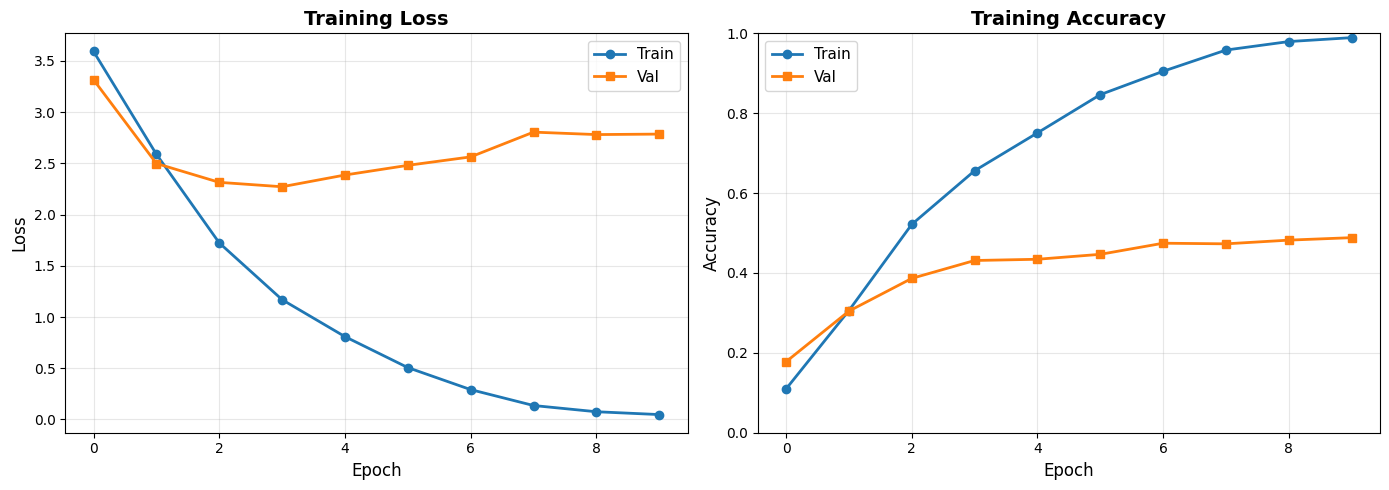

 Plot saved: basicvit_training.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)
axes[1].set_ylim([0, 1])

# Fix for NumPy 2.4.0rc1 compatibility: Skip tight_layout if NumPy 2.4.x
import numpy as np
if np.__version__.startswith('2.4'):
    # NumPy 2.4.0rc1 has bug with matplotlib's tight_layout
    plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.1, wspace=0.3)
    plt.savefig('basicvit_training.png', dpi=100, bbox_inches=None)
else:
    plt.tight_layout()
    plt.savefig('basicvit_training.png', dpi=100, bbox_inches='tight')

plt.show()

print(" Plot saved: basicvit_training.png")


## 10. Inference


 Best model loaded

Batch Predictions:
Sample   Pred Class           Confidence   GT                   Result
----------------------------------------------------------------------
  0       walk                 0.9833       smoke                NO
  1       drink                0.5034       smile                NO
  2       laugh                0.8677       smile                NO


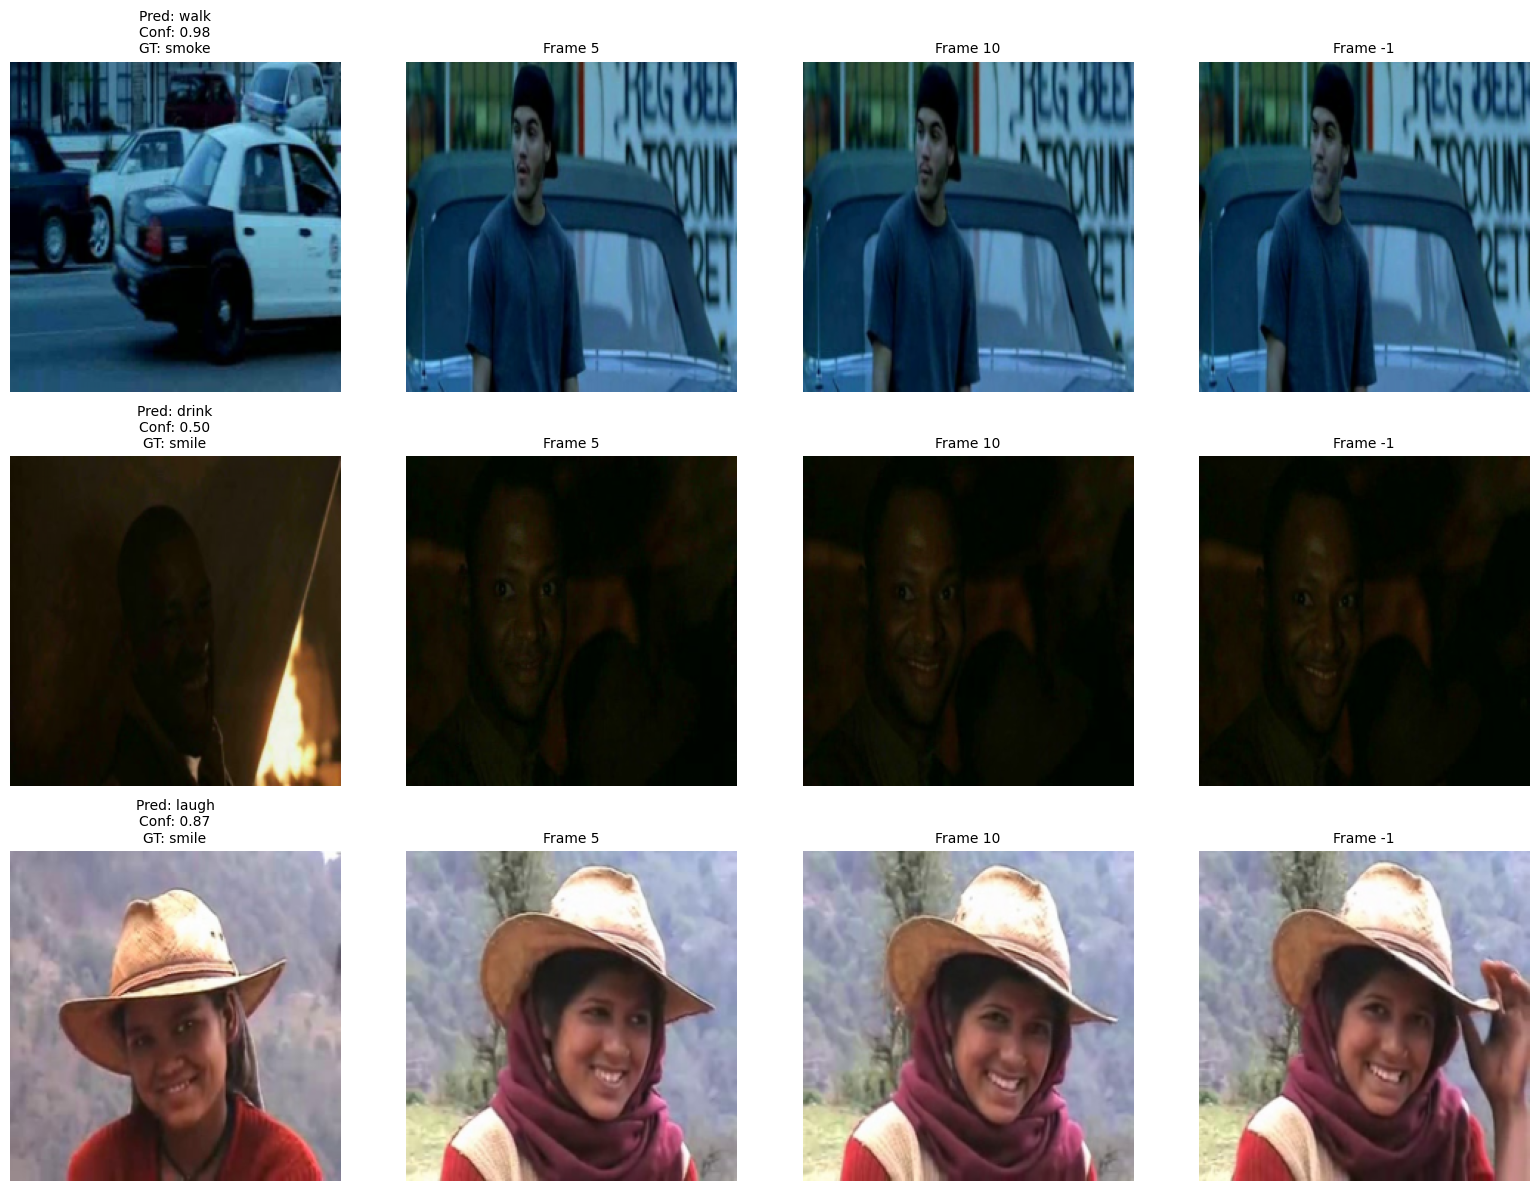


 Visualization saved: inference_results.png


In [21]:
# Load best model
best_model = BasicViT(num_classes=len(train_dataset.classes)).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

print(" Best model loaded\n")

# Predict on validation samples with visualization
with torch.no_grad():
    for videos, labels in val_loader:
        videos_gpu = videos.to(DEVICE)
        outputs = best_model(videos_gpu)
        probs = torch.softmax(outputs, dim=1)

        print(f"Batch Predictions:")
        print(f"{'Sample':<8} {'Pred Class':<20} {'Confidence':<12} {'GT':<20} {'Result'}")
        print("-" * 70)

        # Prepare visualization
        num_samples = min(3, len(labels))
        fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
        if num_samples == 1:
            axes = axes.reshape(1, -1)

        for i in range(num_samples):
            pred = outputs[i].argmax().item()
            conf = probs[i, pred].item()
            gt = labels[i].item()
            match = "YES" if pred == gt else "NO"

            pred_name = train_dataset.classes[pred]
            gt_name = train_dataset.classes[gt]

            print(f"  {i:<7} {pred_name:<20} {conf:<12.4f} {gt_name:<20} {match}")

            # Visualize 4 frames from video
            video = denormalize(videos[i])
            frame_indices = [0, len(video)//3, 2*len(video)//3, -1]

            for j, frame_idx in enumerate(frame_indices):
                frame = video[frame_idx].cpu().numpy().transpose(1, 2, 0)
                axes[i, j].imshow(frame)
                if j == 0:
                    title = f"Pred: {pred_name}\nConf: {conf:.2f}\nGT: {gt_name}"
                else:
                    title = f"Frame {frame_idx}"
                axes[i, j].set_title(title, fontsize=10)
                axes[i, j].axis('off')

        # Fix for NumPy 2.4.0rc1 compatibility: Skip tight_layout if NumPy 2.4.x
        import numpy as np
        if np.__version__.startswith('2.4'):
            # NumPy 2.4.0rc1 has bug with matplotlib's tight_layout
            plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05, wspace=0.2, hspace=0.3)
            plt.savefig('inference_results.png', dpi=100, bbox_inches=None)
        else:
            plt.tight_layout()
            plt.savefig('inference_results.png', dpi=100, bbox_inches='tight')
        
        plt.show()
        print(f"\n Visualization saved: inference_results.png")

        break
